In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../data/drug-sales.csv')

# Convert date column to proper date format
df['date'] = pd.to_datetime(df['date'])

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDate range:")
print(f"  From: {df['date'].min()}")
print(f"  To:   {df['date'].max()}")
print(f"\nSales stats:")
print(df['value'].describe())

Shape: (204, 2)

First 5 rows:
        date     value
0 1991-07-01  3.526591
1 1991-08-01  3.180891
2 1991-09-01  3.252221
3 1991-10-01  3.611003
4 1991-11-01  3.565869

Date range:
  From: 1991-07-01 00:00:00
  To:   2008-06-01 00:00:00

Sales stats:
count    204.000000
mean      10.694430
std        5.956998
min        2.814520
25%        5.844095
50%        9.319345
75%       14.289964
max       29.665356
Name: value, dtype: float64


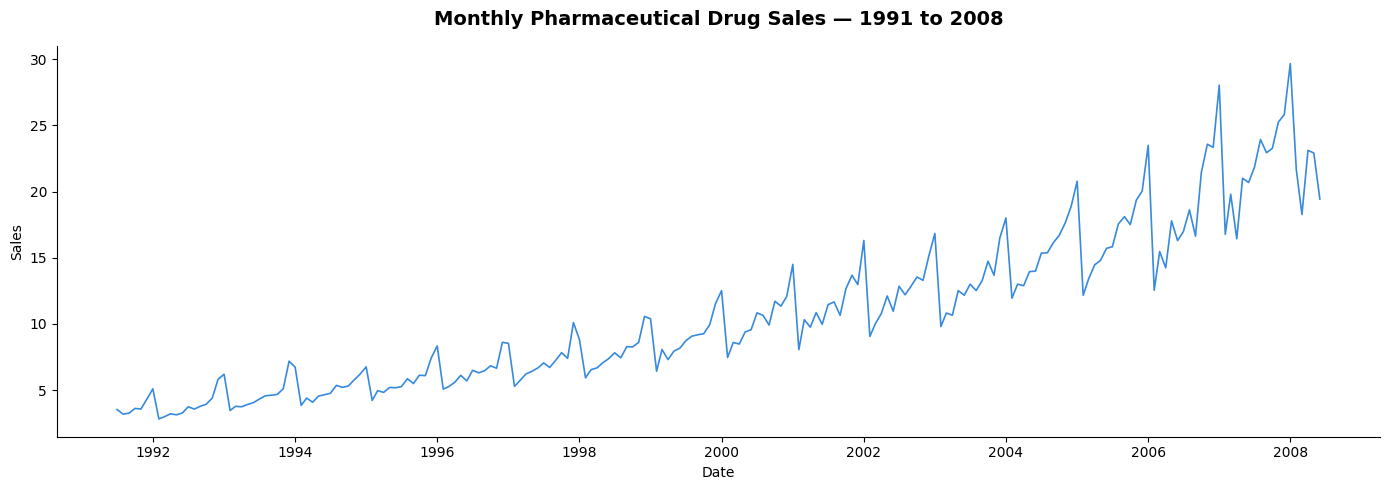

Chart saved.


In [2]:
# Chart 1: Sales over time — the full picture
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['date'], df['value'], 
        color='#378ADD', linewidth=1.2)

ax.set_title('Monthly Pharmaceutical Drug Sales — 1991 to 2008', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/01_sales_over_time.png', dpi=150)
plt.show()
print("Chart saved.")

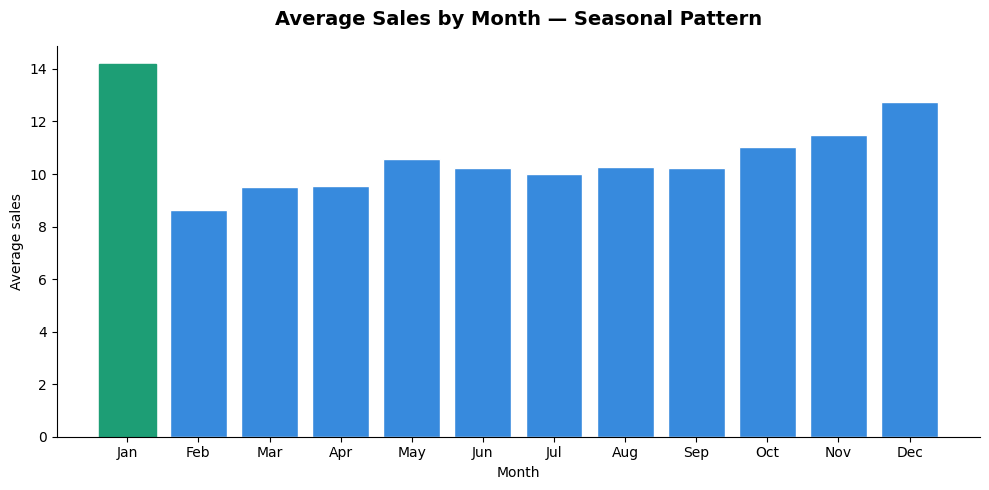

Peak sales month: Jan
Lowest sales month: Feb


In [3]:
# Which months sell the most?
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Calculate average sales per month across all years
monthly_avg = df.groupby('month')['value'].mean()

# Month names for the chart
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(month_names, monthly_avg.values, 
              color='#378ADD', edgecolor='white')

# Highlight the highest month
max_month = monthly_avg.idxmax() - 1
bars[max_month].set_color('#1D9E75')

ax.set_title('Average Sales by Month — Seasonal Pattern', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Average sales')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/02_seasonal_pattern.png', dpi=150)
plt.show()

print("Peak sales month:", month_names[monthly_avg.idxmax()-1])
print("Lowest sales month:", month_names[monthly_avg.idxmin()-1])